# Линейные модели классификации. Наивный байесовский классификатор.

Подключение необходимых библиотек

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

In [2]:
RANDOM_STATE = 42

Загрузка датасета с google drive

In [3]:
# fixed random state for reproducibility
np.random.seed(RANDOM_STATE)

In [4]:
url = "https://drive.google.com/file/d/1BTng9OFk4gbwiTTnWpn4bo65P45txm9z/view?usp=drive_link"
url = "https://drive.google.com/uc?id=" + url.split("/")[-2]
data = pd.read_csv(url)

Получение информации о датасете

In [5]:
print(f"Размер датасета: {data.shape}")

Размер датасета: (2000, 3)


In [6]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      2000 non-null   float64
 1   X2      2000 non-null   float64
 2   Label   2000 non-null   float64
dtypes: float64(3)
memory usage: 47.0 KB
None


In [7]:
print(data.describe())

                X1           X2        Label
count  2000.000000  2000.000000  2000.000000
mean      0.005725     0.007818     0.500000
std       1.459844     1.470398     0.500125
min      -3.150662    -3.174594     0.000000
25%      -1.187908    -1.171769     0.000000
50%       0.007315     0.028933     0.500000
75%       1.199522     1.208300     1.000000
max       3.267570     3.356736     1.000000


array([[<Axes: title={'center': 'X1'}>, <Axes: title={'center': 'X2'}>],
       [<Axes: title={'center': 'Label'}>, <Axes: >]], dtype=object)

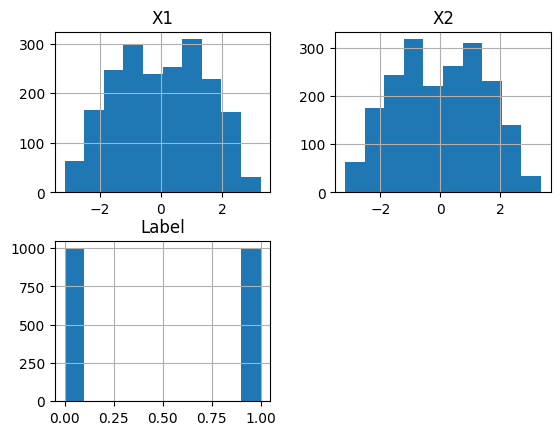

In [8]:
data.hist()

Разделяем признаки и таргеты

In [9]:
X = data[["X1", "X2"]]
Y = data["Label"]

Разделение датасета на обучающую и тестовую выборку

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, train_size=0.8, random_state=RANDOM_STATE, stratify=Y
)

Обучение модели логистической регрессии

In [11]:
model = LogisticRegression(penalty="l2")
model.fit(X_train, Y_train)

LogisticRegression()

Получение прогнозов: метки классов и вероятности

In [12]:
Y_pred = model.predict(X_test)
Y_prob = model.predict_proba(X_test)

Оценим обученную модель с помощью метрики accuracy

In [13]:
Acc_pred = accuracy_score(Y_test, Y_pred)
threshold = 0.5
Acc_prob = accuracy_score(Y_test, Y_prob[:, 1] > 0.5)
print(
    f"Доля правильных ответов с использованием полученной метки класса:",
    np.round(Acc_pred, 4),
)
print(f"Доля правильных ответов с использованием вероятности:", np.round(Acc_prob, 4))
print("Коэффициенты модели:", model.coef_)

Доля правильных ответов с использованием полученной метки класса: 0.5125
Доля правильных ответов с использованием вероятности: 0.5125
Коэффициенты модели: [[ 0.00362483 -0.00524126]]


Построим график зависимости accuracy от значения выбранного порога

In [14]:
thresholds = np.arange(0.01, 1, 0.01)
acc_LR_list = []

In [15]:
for t in thresholds:
    acc_LR = accuracy_score(Y_test, Y_prob[:, 1] > t)
    acc_LR_list.append(acc_LR)

In [16]:
print(acc_LR_list)

[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5125, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]


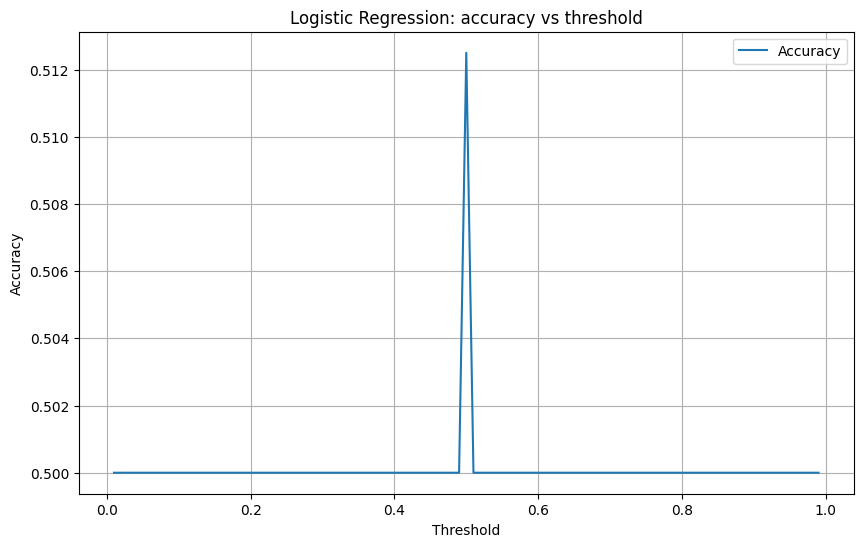

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, acc_LR_list, label="Accuracy")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Logistic Regression: accuracy vs threshold")
plt.legend()
plt.grid(True)
plt.show()

Попробуем использовать наивный байесовский классификатор для решения той же задачи

In [18]:
gnb = GaussianNB()
gnb.fit(X_train, Y_train)
gnb_pred = gnb.predict(X_test)
gnb_prob = gnb.predict_proba(X_test)
gnb_score = accuracy_score(Y_test, gnb_pred)
print(f"Доля правильных ответов NB classifier:", np.round(gnb_score, 4))

Доля правильных ответов NB classifier: 0.945


In [19]:
acc_NB_list = []
for t in thresholds:
    acc_NB = accuracy_score(Y_test, gnb_prob[:, 1] > t)
    acc_NB_list.append(acc_NB)

print(acc_NB_list)

[0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5025, 0.5175, 0.525, 0.5475, 0.5575, 0.5825, 0.61, 0.6525, 0.6875, 0.72, 0.7575, 0.7925, 0.8075, 0.825, 0.8525, 0.89, 0.9025, 0.92, 0.93, 0.9275, 0.94, 0.945, 0.945, 0.9475, 0.9525, 0.9575, 0.9625, 0.9575, 0.955, 0.9425, 0.935, 0.915, 0.9025, 0.89, 0.8875, 0.865, 0.8425, 0.825, 0.8125, 0.79, 0.765, 0.75, 0.7275, 0.705, 0.6925, 0.665, 0.6525, 0.6375, 0.6075, 0.5925, 0.5675, 0.5625, 0.5575, 0.54, 0.5325, 0.525, 0.5175, 0.5175, 0.5125, 0.5075, 0.505, 0.505, 0.505, 0.505, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5]


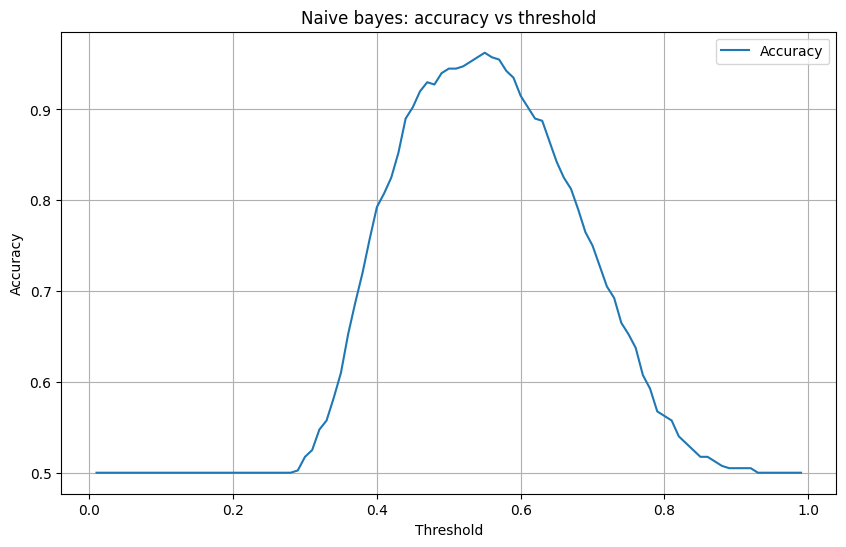

In [20]:
plt.figure(figsize=(10, 6))
plt.plot(thresholds, acc_NB_list, label="Accuracy")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Naive bayes: accuracy vs threshold")
plt.legend()
plt.grid(True)
plt.show()

# Задание для самостоятельной работы
На этом же датасете необходимо получить значение **accuracy > 0.9** на тестовой выборке. <br> Разрешается использовать **только** **логистическую регрессию**

In [21]:
# Your code here